Populating the interactive namespace from numpy and matplotlib
Shape of the image (18054,)


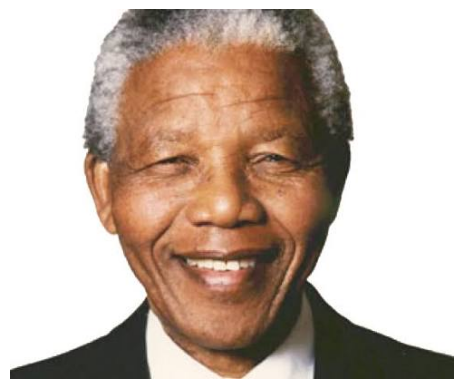

Shape of the image (46823,)


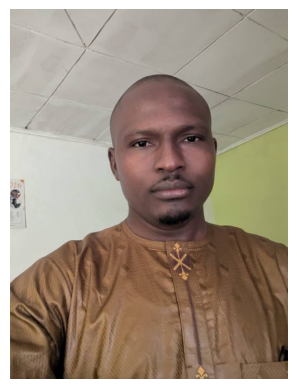

Shape of the image (95511,)


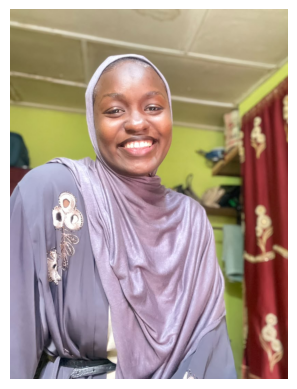

In [1]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import datetime
from tensorflow import keras
from tensorflow.keras.models import Model
import tensorflow as tf

%pylab inline

url_mandela = r'https://github.com/chgoudja-wq/projet_Licence_CNN/blob/main/dataset/Nelson_mandela/nelson_mandela_12.jpg?raw=true'
resp = requests.get(url_mandela, stream=True).raw
image_array_mandela = np.asarray(bytearray(resp.read()), dtype="uint8")
print(f'Shape of the image {image_array_mandela.shape}')
image_mandela = cv2.imdecode(image_array_mandela, cv2.IMREAD_COLOR)
plt.axis('off')
plt.imshow(cv2.cvtColor(image_mandela, cv2.COLOR_BGR2RGB))
plt.show()

url_vagssa = r'https://github.com/chgoudja-wq/projet_Licence_CNN/blob/main/dataset/Dr_vagsa/Dr_vagsa_6.jpeg?raw=true'
resp = requests.get(url_vagssa, stream=True).raw
image_array_vagssa = np.asarray(bytearray(resp.read()), dtype="uint8")
print(f'Shape of the image {image_array_vagssa.shape}')
image_vagssa = cv2.imdecode(image_array_vagssa, cv2.IMREAD_COLOR)
plt.axis('off')
plt.imshow(cv2.cvtColor(image_vagssa, cv2.COLOR_BGR2RGB))
plt.show()



url_aicha = r'https://github.com/chgoudja-wq/projet_Licence_CNN/blob/main/dataset/aicha/aicha_7.jpeg?raw=true'
resp = requests.get(url_aicha, stream=True).raw
image_array_aicha = np.asarray(bytearray(resp.read()), dtype="uint8")
print(f'Shape of the image {image_array_aicha.shape}')
image_aicha = cv2.imdecode(image_array_aicha, cv2.IMREAD_COLOR)
plt.axis('off')
plt.imshow(cv2.cvtColor(image_aicha, cv2.COLOR_BGR2RGB))
plt.show()

(40, 40, 3)
(40, 40)
255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  
255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  
000  000  000  000  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  
000  000  000  000  000  000  000  000  000  000  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  
000  000  000  000  000  000  000  000  000  000  255  000  000  000  000  000  000  000  000  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  255  

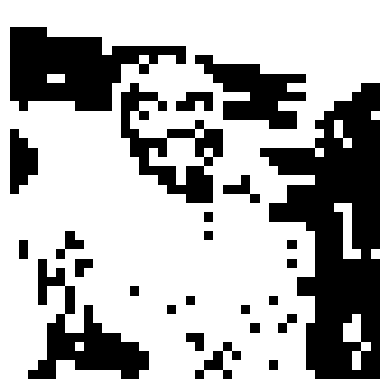

In [4]:
res = cv2.resize(image_aicha , dsize=(40,40), interpolation=cv2.INTER_CUBIC)
print(res.shape)
res = cv2.cvtColor(res,cv2.COLOR_RGB2GRAY) #TO 3D to 1D
print(res.shape)
res = cv2.threshold(res, 127, 255, cv2.THRESH_BINARY)[1]
d = res
for row in range(0,40):
    for col in range(0,40):
        print('%03d ' %d[row][col],end=' ')
    print('')
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
#
#

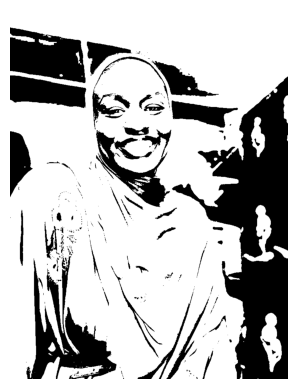

In [6]:
#Convert to bw
img_bw = cv2.imdecode(image_array_aicha, cv2.IMREAD_GRAYSCALE)
(thresh, img_bw) = cv2.threshold(img_bw, 127, 255, cv2.THRESH_BINARY)
plt.axis('off')
plt.imshow(cv2.cvtColor(img_bw, cv2.COLOR_BGR2RGB))

[[0 0 0]
 [0 1 0]
 [0 0 0]]


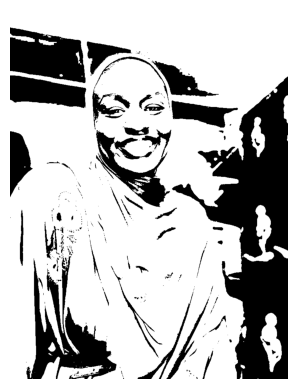

In [8]:
#Définition d'un noyau d'identité : cela ne changera rien car chaque pixel conservera sa valeur.
kernel = np.matrix([[0,0,0],[0,1,0],[0,0,0]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))

[[-10   0  10]
 [-10   0  10]
 [-10   0  10]]


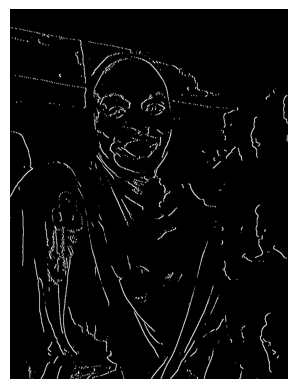

In [9]:
#définition d'un noyau de détection de contours verticaux
kernel = np.matrix([[-10,0,10],[-10,0,10],[-10,0,10]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))

[[ 10  10  10]
 [  0   0   0]
 [-10 -10 -10]]


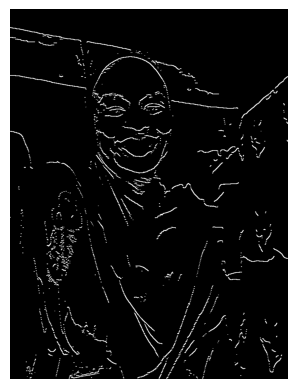

In [10]:
#définition d'un noyau de détection de contours horizontaux
kernel = np.matrix([[10,10,10],[0,0,0],[-10,-10,-10]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))

In [12]:
#exemple
from scipy.ndimage import convolve
m = [[10, 10, 1],[10, 1, 1],[-10, 1, 1]]
k = [[10, 10, 10],[0, 0, 0],[-10, -10, -10]]

c= convolve(m, k , mode='constant', cval=0.0)
print('Matrix')
print('\n'.join([''.join(['{:4}'.format(item) for item in row])
      for row in m]))

print('Kernel')
print('\n'.join([''.join(['{:4}'.format(item) for item in row])
      for row in k]))

print('Convolution')
print('\n'.join([''.join(['{:4}'.format(item) for item in row])
      for row in c]))

Matrix
  10  10   1
  10   1   1
 -10   1   1
Kernel
  10  10  10
   0   0   0
 -10 -10 -10
Convolution
 110 120  20
-290-290 -90
-110-120 -20


(3, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

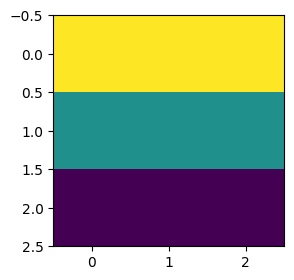

In [14]:
k2 = np.matrix(k)
f_min, f_max = k2.min(), k2.max()
filter = (k2 - f_min) / (f_max - f_min)
print(k2.shape)
fig= plt.figure(figsize=(3,3))
plt.imshow(k2)
plt.show

In [15]:
#Import dataset
import pathlib
import os
data_dir = tf.keras.utils.get_file(
    "dataset.zip",
    "https://github.com/chgoudja-wq/projet_Licence_CNN/blob/main/dataset.zip?raw=true",
    extract=False)

import zipfile
with zipfile.ZipFile(data_dir, 'r') as zip_ref:
    zip_ref.extractall('/content/datasets')

data_dir = pathlib.Path('/content/datasets/dataset')
print(data_dir)
print(os.path.abspath(data_dir))

2612448/2612448 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/content/datasets/dataset
/content/datasets/dataset


In [16]:
image_count = len(list(data_dir.glob('*/*')))
print(image_count)

57


In [22]:
batch_size = 3
img_height = 200
img_width = 200

train_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  )

val_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = val_data.class_names
print(class_names)

Found 57 files belonging to 3 classes.
Using 46 files for training.
Found 57 files belonging to 3 classes.
Using 11 files for validation.
['Dr_vagsa', 'aicha', 'mandela']


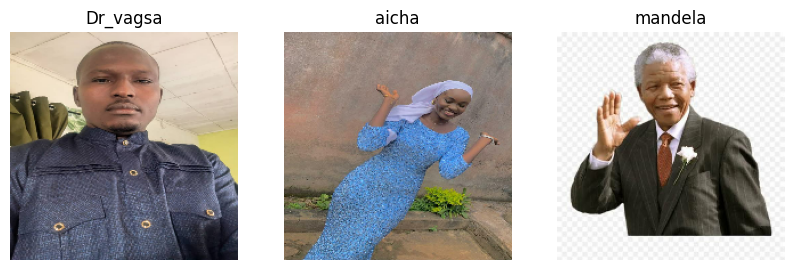

In [27]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 3

model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(128, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

logdir = "logs"
tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir=logdir,
    histogram_freq=1,
    write_images=True
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6957 - loss: 0.9140 - val_accuracy: 0.8182 - val_loss: 0.6500
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7391 - loss: 0.8017 - val_accuracy: 0.8182 - val_loss: 0.5387


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 197, 197, 128)  │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 98, 98, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 95, 95, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 32)     │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 16)     │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        83,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,664 (2.99 MB)

 Trainable params: 261,554 (1021.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 523,110 (2.00 MB)

Saving aicha_3.jpeg to aicha_3 (1).jpeg


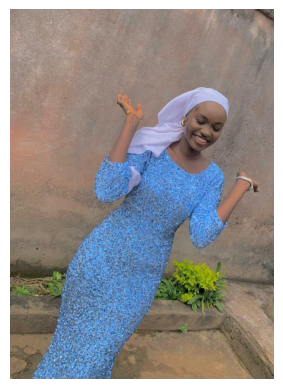

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Probabilités : [[0.18641184 0.17467274 0.6389154 ]]
Classe prédite : 2
Nom de la classe : mandela


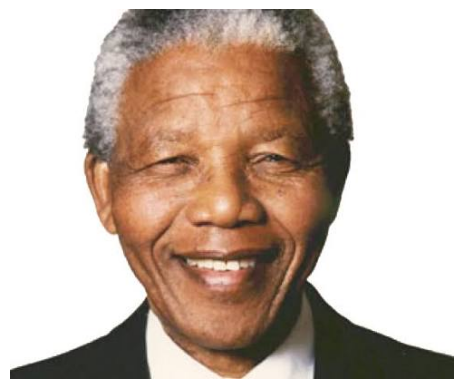

IL S'AGIT DE MANDELA !


In [39]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Dr_vagsa", "aicha", "mandela"]

file_to_predict = files.upload()

for file_ in file_to_predict:
    image_to_predict = cv2.imread(file_, cv2.IMREAD_COLOR)
    plt.imshow(cv2.cvtColor(image_to_predict, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    img_to_predict = cv2.resize(image_to_predict, (200, 200))
    img_to_predict = np.expand_dims(img_to_predict, axis=0)

    pred = model.predict(img_to_predict)
    print("Probabilités :", pred)

    res = np.argmax(pred, axis=1)[0]
    print("Classe prédite :", res)
    print("Nom de la classe :", class_names[res])

    if res == 0:
        plt.imshow(cv2.cvtColor(image_vagssa, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        print("IL S'AGIT DE  Dr VAGSSA  !")
    elif res == 1:
        plt.imshow(cv2.cvtColor(image_aicha, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        print("IL S'AGIT DE  AICHA !")
    elif res == 2:
        plt.imshow(cv2.cvtColor(image_mandela , cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        print("IL S'AGIT DE MANDELA !")

#Understand the filters mades by the CNN

In [32]:
from tensorflow.keras.models import Model
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

def display_image_filtered(name_image, model, layer_name, image):
    # Vérifier que la couche existe
    try:
        out1 = model.get_layer(layer_name).output
    except ValueError:
        print(f"⚠️ Couche {layer_name} introuvable dans le modèle.")
        print([layer.name for layer in model.layers])
        return

    inp = model.inputs
    feature_map_1 = Model(inputs=inp, outputs=out1)

    # Adapter la taille à celle attendue par le modèle
    # Ici ton modèle semble être en 200x200, sinon tu peux utiliser model.input_shape
    img = cv2.resize(image, (200, 200))

    # Prétraitement éventuel (à adapter à ce que tu as fait à l'entraînement)
    img = img.astype("float32") / 255.0

    input_img = np.expand_dims(img, axis=0)

    # Prédiction et récupération des feature maps
    f = feature_map_1.predict(input_img)

    # On suppose une sortie 4D : (batch, h, w, channels)
    if len(f.shape) != 4:
        print(f"⚠️ La couche {layer_name} ne renvoie pas un tenseur 4D, shape = {f.shape}")
        return

    dim = f.shape[3]

    print(f'{layer_name} | Features Shape: {f.shape}')
    print(f'Dimension (nb de filtres) = {dim}')

    # Création du dossier de sortie
    results_dir = f'results_{name_image}'
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Grille de subplots compacte
    n_cols = int(np.ceil(np.sqrt(dim)))
    n_rows = int(np.ceil(dim / n_cols))

    fig = plt.figure(figsize=(n_cols * 2, n_rows * 2))

    for i in range(dim):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        ax.axis('off')
        ax.imshow(f[0, :, :, i], cmap='viridis')

        # Sauvegarde des feature maps
        plt.imsave(
            os.path.join(results_dir, f'{name_image}_{layer_name}_{i}.jpg'),
            f[0, :, :, i],
            cmap='viridis'
        )

    plt.tight_layout()
    plt.show()


# Utilisation des vrais noms de couches de ton modèle
# D'après le message d'erreur, ton modèle a ces couches :
# ['rescaling', 'conv2d', 'max_pooling2d',
#  'conv2d_1', 'max_pooling2d_1',
#  'conv2d_2', 'max_pooling2d_2',
#  'conv2d_3', 'max_pooling2d_3',
#  'flatten', 'dense', 'dense_1']

conv_layers = ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']
pool_layers = ['max_pooling2d', 'max_pooling2d_1', 'max_pooling2d_2', 'max_pooling2d_3']

# Vérification des noms de couches (optionnel mais utile)
print([layer.name for layer in model.layers])

# Boucle sur les deux images : pikachu et rondoudou
for name in ['pikachu', 'rondoudou']:
    if name == 'pikachu':
        image = image_pikachu
    elif name == 'rondoudou':
        image = image_rondoudou

    # Afficher l'image courante
    plt.axis('off')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

    # Parcourir les 4 couples Conv + Pool
    for i in range(4):
        conv_name = conv_layers[i]
        pool_name = pool_layers[i]

        print('-----------------------------------------------------')
        print(f'{i+1}e couche convolutionnelle : {conv_name}')
        display_image_filtered(name, model, conv_name, image)

        print('--------')
        print(f'{i+1}e couche de pooling : {pool_name}')
        display_image_filtered(name, model, pool_name, image)
        print('-----------------------------------------------------')

['rescaling_1', 'conv2d_4', 'max_pooling2d_4', 'conv2d_5', 'max_pooling2d_5', 'conv2d_6', 'max_pooling2d_6', 'conv2d_7', 'max_pooling2d_7', 'flatten_1', 'dense_2', 'dense_3']


NameError: name 'image_pikachu' is not defined

In [ ]:
from google.colab import files
#if there is a bug please be sure pikachu and rondoudou filters are finished to be displayed. If so just relaunch this cell ;)
!zip -r /content/results_pikachu.zip /content/results_pikachu
!zip -r /content/results_rondoudou.zip /content/results_rondoudou

  adding: content/results_pikachu/ (stored 0%)
  adding: content/results_pikachu/pikachu_max_pooling2d_118.jpg (deflated 45%)
  adding: content/results_pikachu/pikachu_conv2d_1_36.jpg (deflated 41%)
  adding: content/results_pikachu/pikachu_max_pooling2d_55.jpg (deflated 45%)
  adding: content/results_pikachu/pikachu_max_pooling2d_11.jpg (deflated 45%)
  adding: content/results_pikachu/pikachu_conv2d_1_1.jpg (deflated 41%)
  adding: content/results_pikachu/pikachu_conv2d_1_61.jpg (deflated 6%)
  adding: content/results_pikachu/pikachu_max_pooling2d_42.jpg (deflated 45%)
  adding: content/results_pikachu/pikachu_conv2d_3_12.jpg (deflated 30%)
  adding: content/results_pikachu/pikachu_max_pooling2d_125.jpg (deflated 45%)
  adding: content/results_pikachu/pikachu_conv2d_2_24.jpg (deflated 32%)
  adding: content/results_pikachu/pikachu_max_pooling2d_77.jpg (deflated 6%)
  adding: content/results_pikachu/pikachu_max_pooling2d_110.jpg (deflated 7%)
  adding: content/results_pikachu/pikachu_c

In [ ]:
files.download("/content/results_pikachu.zip")
files.download("/content/results_rondoudou.zip")

In [ ]:
def display_filter(model, layer_name):
    layer = model.get_layer(layer_name)
    filter, bias= layer.get_weights()
    dim = filter.shape[3]
    print(f'{layer_name} | Filter Shape: {filter.shape} Bias Shape: {bias.shape}')
    print(f'Dimension {dim}')
    f_min, f_max = filter.min(), filter.max()
    filter = (filter - f_min) / (f_max - f_min)
    print(filter.shape)
    fig= plt.figure(figsize=(30,30))
    for i in range(dim):
        ax = fig.add_subplot(dim/2,dim/2,i+1)
        ax.axis('off')
        try:
            ax.imshow(filter[:,:,:,i])
        except:
            ax.imshow(filter[:,:,:,i][0])

display_filter(model,f'conv2d_{num}')

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs